AIR QUALITY DATA ANALYSIS

1. INITIAL DATA OVERVIEW
--------------------------------------------------------------------------------
Dataset Shape: 3445 rows × 11 columns

Column Names and Types:
country              str
state                str
city                 str
station              str
last_update          str
latitude         float64
longitude        float64
pollutant_id         str
pollutant_min    float64
pollutant_max    float64
pollutant_avg    float64
dtype: object

2. DATA QUALITY ASSESSMENT
--------------------------------------------------------------------------------

Missing Values Analysis:
           Column  Missing_Count  Missing_Percentage
8   pollutant_min            208            6.037736
9   pollutant_max            208            6.037736
10  pollutant_avg            208            6.037736

Checking for 'NA' string values...
  No 'NA' string values found

3. DATA CLEANING
--------------------------------------------------------------------------------

Cl

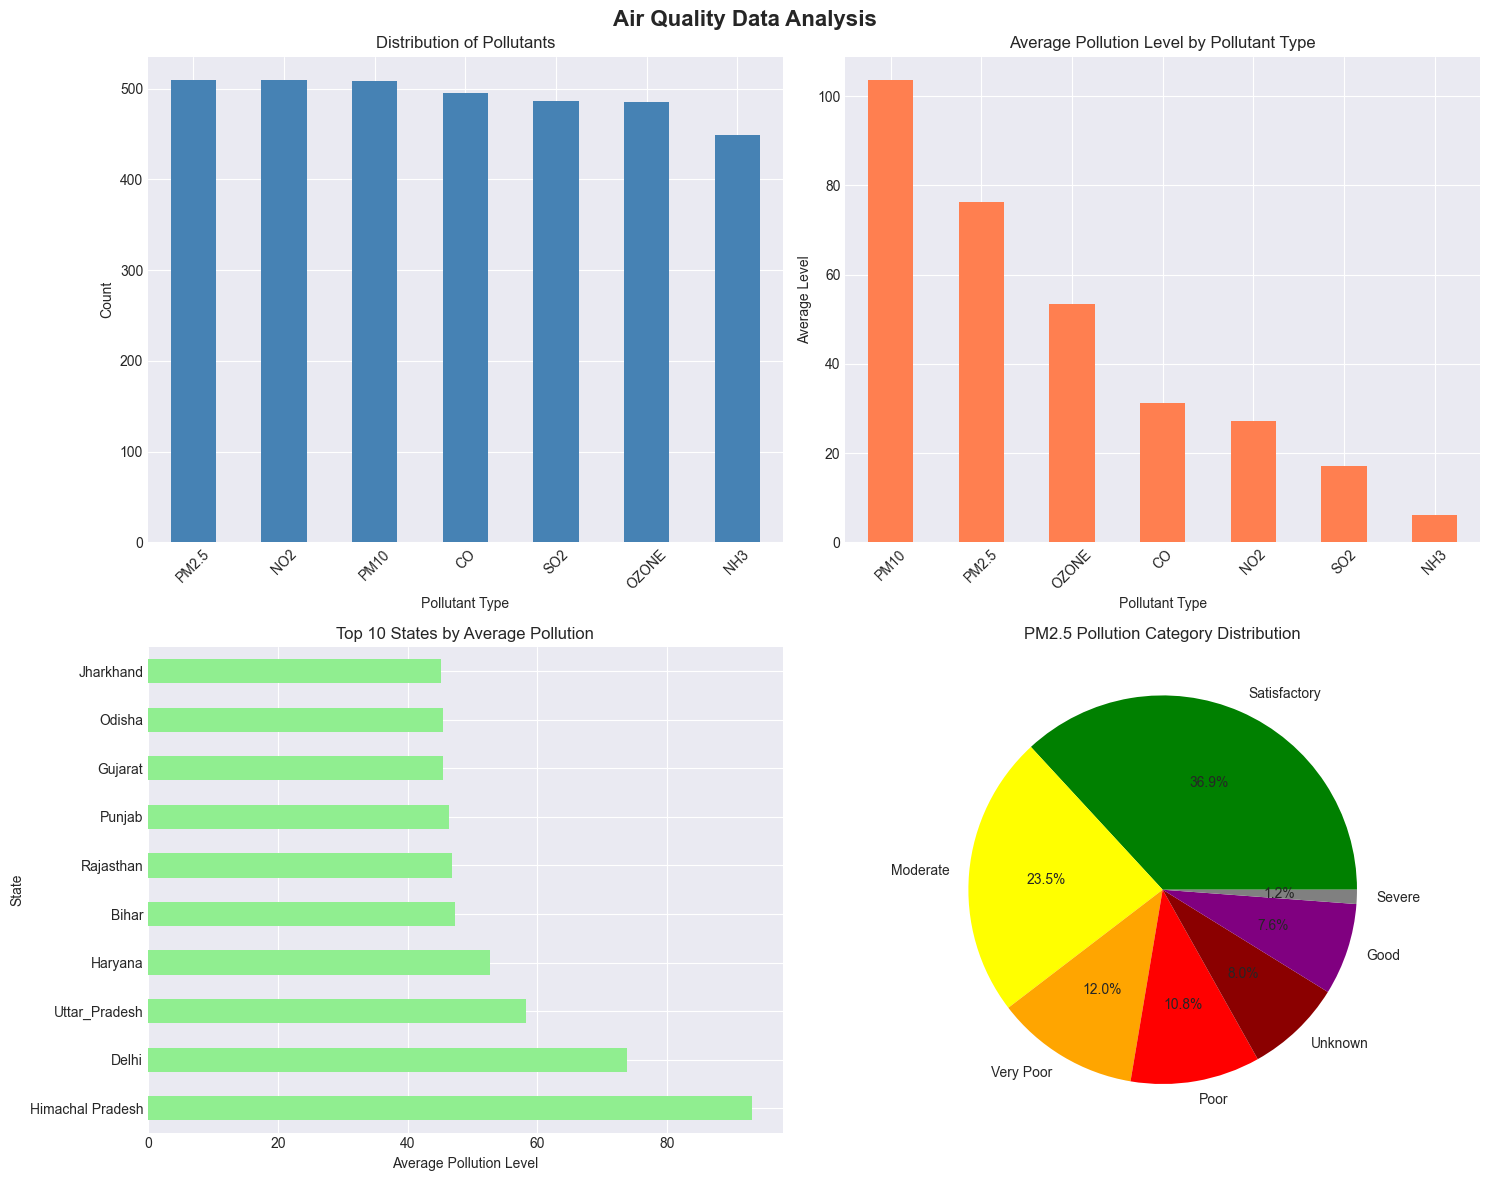

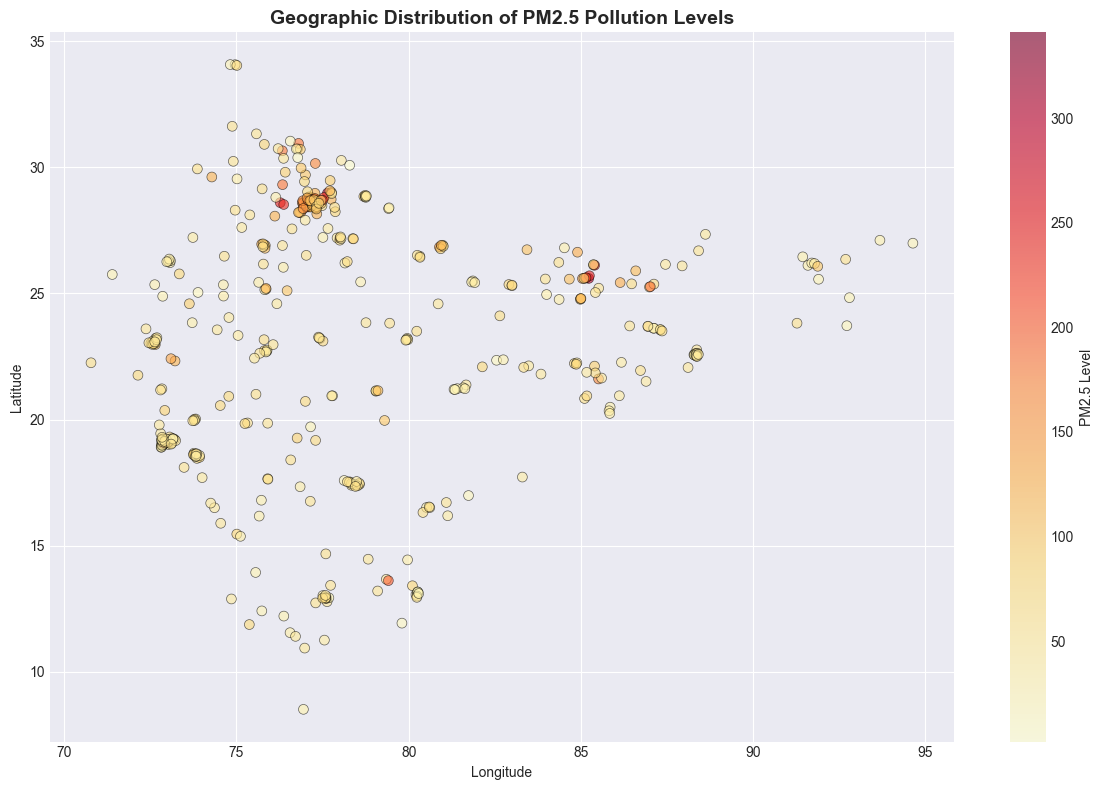

In [ ]:
"""
Air Quality Data Analysis and Cleaning Script
==============================================
This script performs comprehensive data analysis and cleaning on the air quality dataset.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the dataset
print("="*80)
print("AIR QUALITY DATA ANALYSIS")
print("="*80)

df = pd.read_csv(r'C:\Users\vaish\OneDrive\Desktop\Assignment\air_quality.csv')

print("\n1. INITIAL DATA OVERVIEW")
print("-"*80)
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn Names and Types:")
print(df.dtypes)

# Basic statistics
print("\n2. DATA QUALITY ASSESSMENT")
print("-"*80)

# Missing values
print("\nMissing Values Analysis:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})
print(missing_df[missing_df['Missing_Count'] > 0])

# Check for 'NA' strings (common in CSV files)
print("\nChecking for 'NA' string values...")
na_counts = {}
for col in df.columns:
    if df[col].dtype == 'object':
        na_count = (df[col] == 'NA').sum()
        if na_count > 0:
            na_counts[col] = na_count
            
if na_counts:
    print("Columns with 'NA' string values:")
    for col, count in na_counts.items():
        print(f"  {col}: {count} occurrences")
else:
    print("  No 'NA' string values found")

# Data cleaning steps
print("\n3. DATA CLEANING")
print("-"*80)

# Create a copy for cleaning
df_clean = df.copy()

# Clean whitespace in all string columns
print("\nCleaning whitespace from text columns...")
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = df_clean[col].str.strip()

# Replace 'NA' strings with actual NaN
print("Converting 'NA' strings to NaN...")
df_clean = df_clean.replace('NA', np.nan)

# Convert numeric columns that might be stored as strings
numeric_cols = ['pollutant_min', 'pollutant_max', 'pollutant_avg', 'latitude', 'longitude']
print(f"Converting numeric columns: {numeric_cols}")
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Parse datetime
print("Parsing datetime column...")
df_clean['last_update'] = pd.to_datetime(df_clean['last_update'], format='%d-%m-%Y %H:%M:%S', errors='coerce')

# Extract date components
df_clean['date'] = df_clean['last_update'].dt.date
df_clean['year'] = df_clean['last_update'].dt.year
df_clean['month'] = df_clean['last_update'].dt.month
df_clean['day'] = df_clean['last_update'].dt.day
df_clean['hour'] = df_clean['last_update'].dt.hour
df_clean['day_name'] = df_clean['last_update'].dt.day_name()

print(f"\nAfter cleaning: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")

# Calculate pollution range
df_clean['pollutant_range'] = df_clean['pollutant_max'] - df_clean['pollutant_min']

# Categorize pollution levels (based on AQI standards)
def categorize_pm25(value):
    if pd.isna(value):
        return 'Unknown'
    elif value <= 30:
        return 'Good'
    elif value <= 60:
        return 'Satisfactory'
    elif value <= 90:
        return 'Moderate'
    elif value <= 120:
        return 'Poor'
    elif value <= 250:
        return 'Very Poor'
    else:
        return 'Severe'

def categorize_pm10(value):
    if pd.isna(value):
        return 'Unknown'
    elif value <= 50:
        return 'Good'
    elif value <= 100:
        return 'Satisfactory'
    elif value <= 250:
        return 'Moderate'
    elif value <= 350:
        return 'Poor'
    elif value <= 430:
        return 'Very Poor'
    else:
        return 'Severe'

# Apply categorization based on pollutant type
df_clean['pollution_category'] = 'Unknown'
pm25_mask = df_clean['pollutant_id'] == 'PM2.5'
pm10_mask = df_clean['pollutant_id'] == 'PM10'

df_clean.loc[pm25_mask, 'pollution_category'] = df_clean.loc[pm25_mask, 'pollutant_avg'].apply(categorize_pm25)
df_clean.loc[pm10_mask, 'pollution_category'] = df_clean.loc[pm10_mask, 'pollutant_avg'].apply(categorize_pm10)

print("\n4. EXPLORATORY DATA ANALYSIS")
print("-"*80)

# Unique values in categorical columns
print("\nUnique Values Summary:")
print(f"Countries: {df_clean['country'].nunique()}")
print(f"States: {df_clean['state'].nunique()}")
print(f"Cities: {df_clean['city'].nunique()}")
print(f"Stations: {df_clean['station'].nunique()}")
print(f"Pollutants: {df_clean['pollutant_id'].nunique()}")

print(f"\nPollutant Types:")
print(df_clean['pollutant_id'].value_counts())

# Statistics by pollutant
print("\n5. POLLUTANT STATISTICS")
print("-"*80)
pollutant_stats = df_clean.groupby('pollutant_id').agg({
    'pollutant_min': ['min', 'mean', 'max'],
    'pollutant_max': ['min', 'mean', 'max'],
    'pollutant_avg': ['count', 'min', 'mean', 'median', 'max', 'std']
}).round(2)
print(pollutant_stats)

# Top polluted cities
print("\n6. TOP 10 MOST POLLUTED CITIES (by average PM2.5)")
print("-"*80)
pm25_data = df_clean[df_clean['pollutant_id'] == 'PM2.5']
top_cities = pm25_data.groupby('city')['pollutant_avg'].mean().sort_values(ascending=False).head(10)
print(top_cities)

# State-wise analysis
print("\n7. STATE-WISE POLLUTION SUMMARY")
print("-"*80)
state_stats = df_clean.groupby('state').agg({
    'city': 'nunique',
    'station': 'nunique',
    'pollutant_avg': ['mean', 'max']
}).round(2)
state_stats.columns = ['Unique_Cities', 'Unique_Stations', 'Avg_Pollution', 'Max_Pollution']
state_stats = state_stats.sort_values('Avg_Pollution', ascending=False)
print(state_stats.head(15))

# Save cleaned data
print("\n8. SAVING CLEANED DATA")
print("-"*80)
output_file = r'C:\Users\vaish\OneDrive\Desktop\Assignment\air_quality_cleaned.csv'
df_clean.to_csv(output_file, index=False)
print(f"Cleaned data saved to: {output_file}")

# Create summary statistics file
summary_stats = {
    'Total_Records': len(df_clean),
    'Unique_States': df_clean['state'].nunique(),
    'Unique_Cities': df_clean['city'].nunique(),
    'Unique_Stations': df_clean['station'].nunique(),
    'Unique_Pollutants': df_clean['pollutant_id'].nunique(),
    'Date_Range': f"{df_clean['last_update'].min()} to {df_clean['last_update'].max()}",
    'Missing_Values': df_clean.isnull().sum().sum(),
    'Average_PM25': df_clean[df_clean['pollutant_id'] == 'PM2.5']['pollutant_avg'].mean(),
    'Average_PM10': df_clean[df_clean['pollutant_id'] == 'PM10']['pollutant_avg'].mean()
}

print("\n9. DATASET SUMMARY")
print("-"*80)
for key, value in summary_stats.items():
    print(f"{key}: {value}")

# Create visualizations
print("\n10. CREATING VISUALIZATIONS")
print("-"*80)

# Figure 1: Pollutant Distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Air Quality Data Analysis', fontsize=16, fontweight='bold')

# Pollutant count
ax1 = axes[0, 0]
pollutant_counts = df_clean['pollutant_id'].value_counts()
pollutant_counts.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Distribution of Pollutants')
ax1.set_xlabel('Pollutant Type')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# Average pollution by pollutant
ax2 = axes[0, 1]
pollutant_avg = df_clean.groupby('pollutant_id')['pollutant_avg'].mean().sort_values(ascending=False)
pollutant_avg.plot(kind='bar', ax=ax2, color='coral')
ax2.set_title('Average Pollution Level by Pollutant Type')
ax2.set_xlabel('Pollutant Type')
ax2.set_ylabel('Average Level')
ax2.tick_params(axis='x', rotation=45)

# Top 10 states by pollution
ax3 = axes[1, 0]
state_pollution = df_clean.groupby('state')['pollutant_avg'].mean().sort_values(ascending=False).head(10)
state_pollution.plot(kind='barh', ax=ax3, color='lightgreen')
ax3.set_title('Top 10 States by Average Pollution')
ax3.set_xlabel('Average Pollution Level')
ax3.set_ylabel('State')

# Pollution category distribution for PM2.5
ax4 = axes[1, 1]
pm25_categories = df_clean[df_clean['pollutant_id'] == 'PM2.5']['pollution_category'].value_counts()
colors = ['green', 'yellow', 'orange', 'red', 'darkred', 'purple', 'gray']
ax4.pie(pm25_categories.values, labels=pm25_categories.index, autopct='%1.1f%%', colors=colors[:len(pm25_categories)])
ax4.set_title('PM2.5 Pollution Category Distribution')

plt.tight_layout()
plt.savefig(r'C:\Users\vaish\OneDrive\Desktop\Assignment\air_quality_analysis.png', dpi=300, bbox_inches='tight')
print("Visualization saved: air_quality_analysis.png")

# Figure 2: Geographic Distribution
fig2, ax = plt.subplots(1, 1, figsize=(12, 8))
# Sample data for scatter plot (to avoid overcrowding)
sample_data = df_clean[df_clean['pollutant_id'] == 'PM2.5'].dropna(subset=['latitude', 'longitude', 'pollutant_avg'])
if len(sample_data) > 500:
    sample_data = sample_data.sample(500)

scatter = ax.scatter(sample_data['longitude'], sample_data['latitude'], 
                     c=sample_data['pollutant_avg'], cmap='YlOrRd', 
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax.set_title('Geographic Distribution of PM2.5 Pollution Levels', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.colorbar(scatter, ax=ax, label='PM2.5 Level')
plt.tight_layout()
plt.savefig(r'C:\Users\vaish\OneDrive\Desktop\Assignment\geographic_distribution.png', dpi=300, bbox_inches='tight')
print("Geographic visualization saved: geographic_distribution.png")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print(f"\nFiles created:")
print(f"1. air_quality_cleaned.csv - Cleaned dataset with additional columns")
print(f"2. air_quality_analysis.png - Data analysis visualizations")
print(f"3. geographic_distribution.png - Geographic pollution distribution")